In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [ ]:
list_c_vals=[np.float64(0.9930733865293206), np.float64(0.9920967260182538), np.float64(0.9909671201993773), np.float64(0.989884569072691), np.float64(0.9886490726381949), np.float64(0.9873606308958891), np.float64(0.9860192438457734), np.float64(0.9845249114878482), np.float64(0.9829776338221131), np.float64(0.9813774108485682), np.float64(0.9797242425672137), np.float64(0.9778181289780494), np.float64(0.9759590700810754), np.float64(0.9739470658762915), np.float64(0.971782116363698), np.float64(0.9695642215432947), np.float64(0.9670933814150816), np.float64(0.9646695959790589), np.float64(0.9621928652352263), np.float64(0.9591631891835839)]
list_ef_AC_stark_vals=[np.float64(1.9848907245309517), np.float64(1.9326217272530353), np.float64(1.8874574125355859), np.float64(1.8532977803786037), np.float64(1.8243428307820888), np.float64(1.7795925637460406), np.float64(1.7607469792704598), np.float64(1.6987060773553462), np.float64(1.6576698580006997), np.float64(1.6236383212065206), np.float64(1.5903114669728082), np.float64(1.5349892952995634), np.float64(1.4927718061867854), np.float64(1.4361589996344748), np.float64(1.3832508756426312), np.float64(1.327347434211255), np.float64(1.2630486753403458), np.float64(1.2030545990299033), np.float64(1.1460652052799285), np.float64(1.0801804940904207)]


## Simulaatio

In [5]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [6]:
def find_params(f_1,f_2,f_supp,A,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        delta=qubit.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 2.9:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=5,U_f=10,f_2=f_2_shifted,K=200, drag=True)
        elif A < 3.7:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,f_2=f_2_shifted,K=200, drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1_shifted,f_supp,A,evolution,dim,f_rabi,t_ramp=5,U_f=1,f_2=f_2_shifted,K=200, drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    delta=AC_stark_vals[index]
    c=c_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

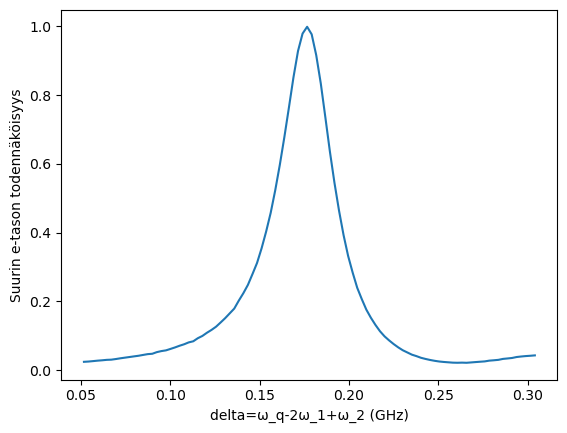

Amplitudi (GHz): 2.0390881111606896
AC-stark siirtymä (GHz): 0.17654968973334917
E-tason suurin todennäköisyys: 0.9987921365234977
Pulssin pituus (ns): 208.5832008152977
Rabi-taajuus (fourier):  0.0027158684142585474


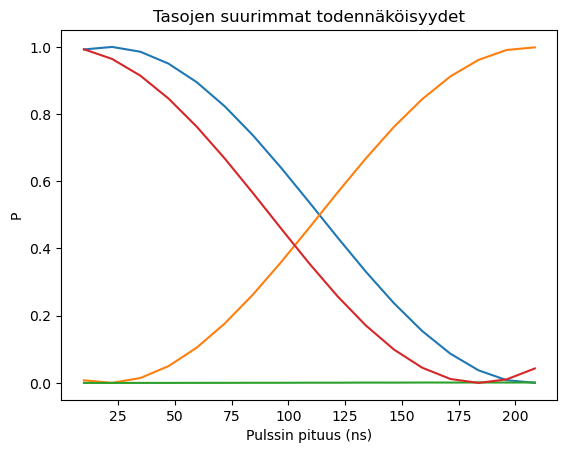

---------------------------------------------


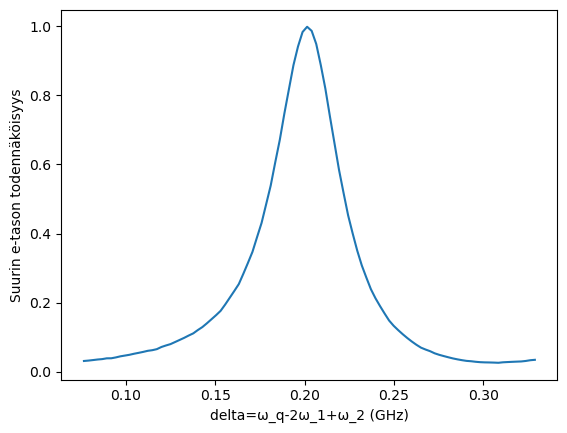

Amplitudi (GHz): 2.173238644789682
AC-stark siirtymä (GHz): 0.20144340019280094
E-tason suurin todennäköisyys: 0.9987393818319121
Pulssin pituus (ns): 171.5076890567263
Rabi-taajuus (fourier):  0.0033078708417084864


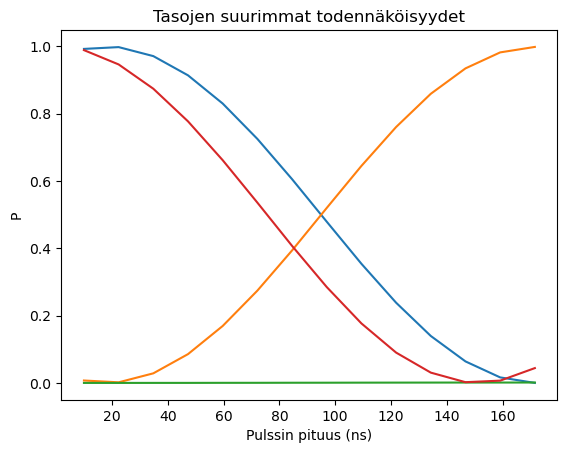

---------------------------------------------


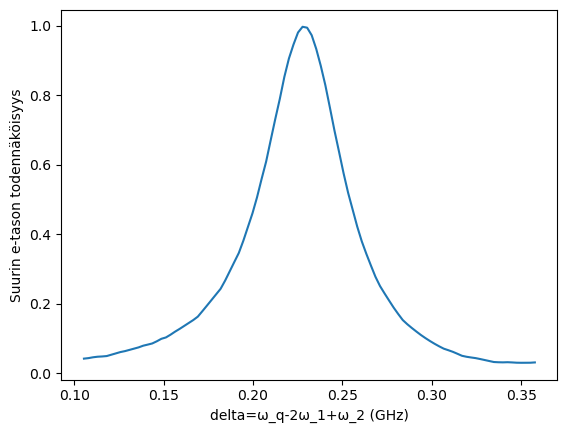

Amplitudi (GHz): 2.307389178418675
AC-stark siirtymä (GHz): 0.22768661249846645
E-tason suurin todennäköisyys: 0.9970177930380887
Pulssin pituus (ns): 146.8023268141436
Rabi-taajuus (fourier):  0.003987173012017457


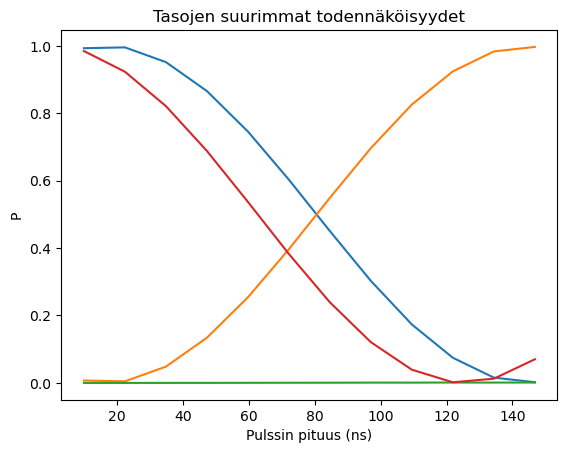

---------------------------------------------


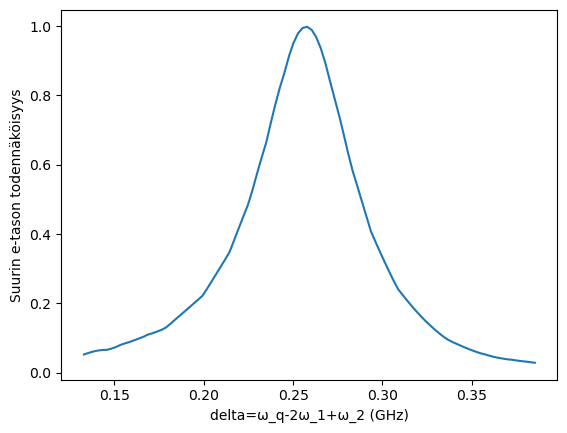

Amplitudi (GHz): 2.4415397120476676
AC-stark siirtymä (GHz): 0.25782818678928976
E-tason suurin todennäköisyys: 0.9984911524408823
Pulssin pituus (ns): 122.06289103839585
Rabi-taajuus (fourier):  0.004724237968521543


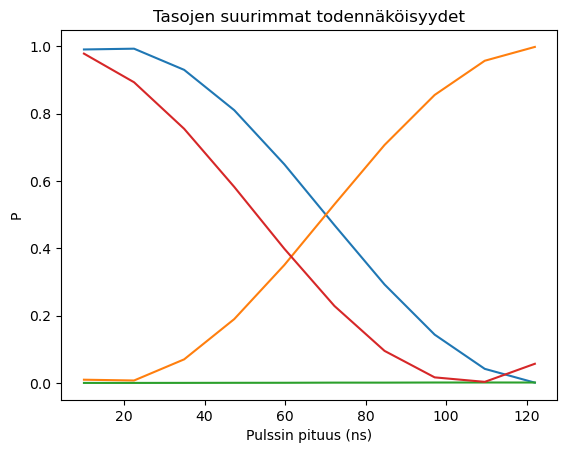

---------------------------------------------


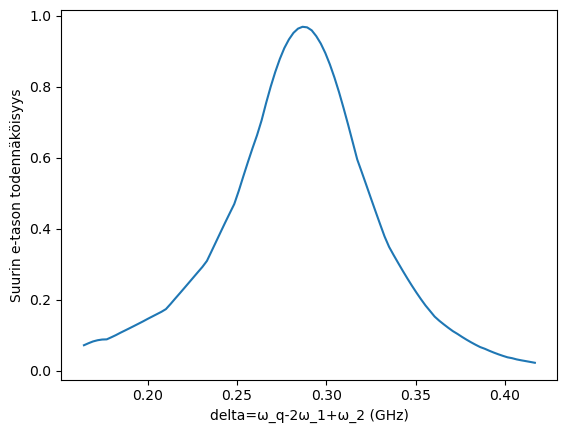

Amplitudi (GHz): 2.57569024567666
AC-stark siirtymä (GHz): 0.28677040278736143
E-tason suurin todennäköisyys: 0.9953771927068157
Pulssin pituus (ns): 97.26012243600714
Rabi-taajuus (fourier):  0.00553240824345267


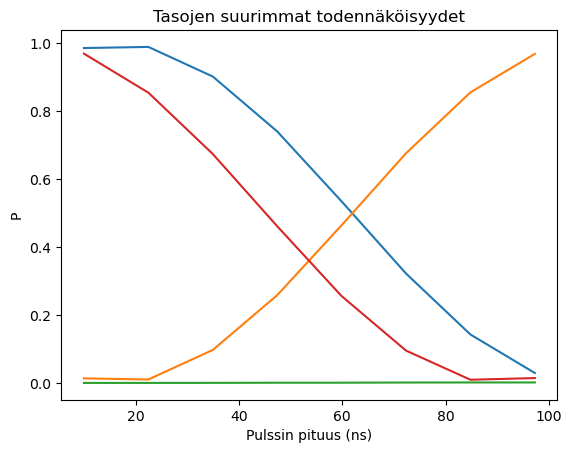

---------------------------------------------


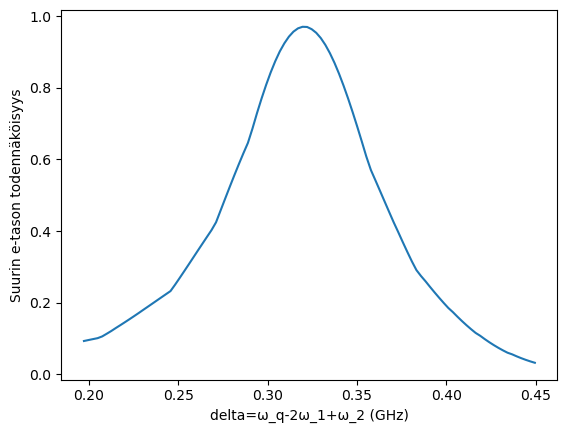

Amplitudi (GHz): 2.7098407793056527
AC-stark siirtymä (GHz): 0.319610980770598
E-tason suurin todennäköisyys: 0.9976037875106188
Pulssin pituus (ns): 84.8919826160158
Rabi-taajuus (fourier):  0.00649584200462134


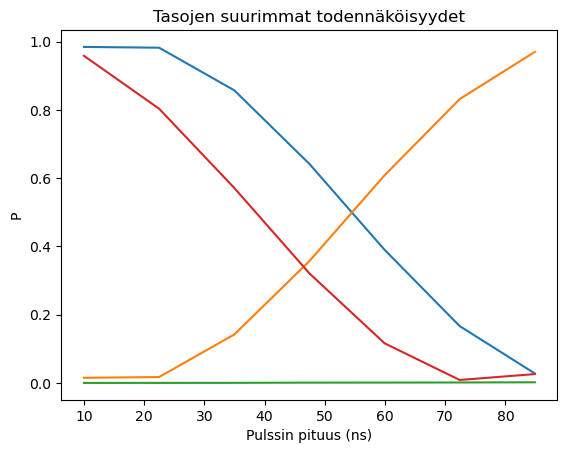

---------------------------------------------


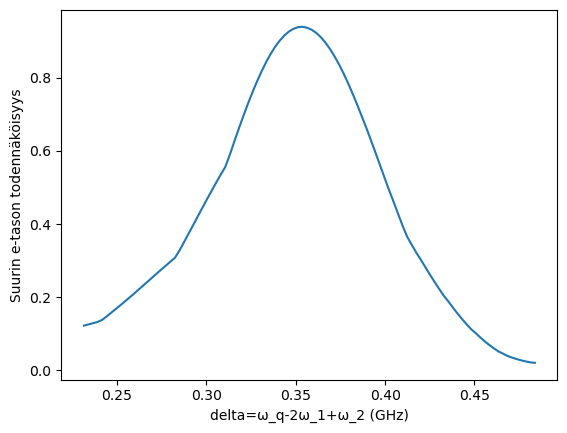

Amplitudi (GHz): 2.8439913129346457
AC-stark siirtymä (GHz): 0.35380106060004834
E-tason suurin todennäköisyys: 0.9973764470897155
Pulssin pituus (ns): 72.49487985740069
Rabi-taajuus (fourier):  0.007619671839949704


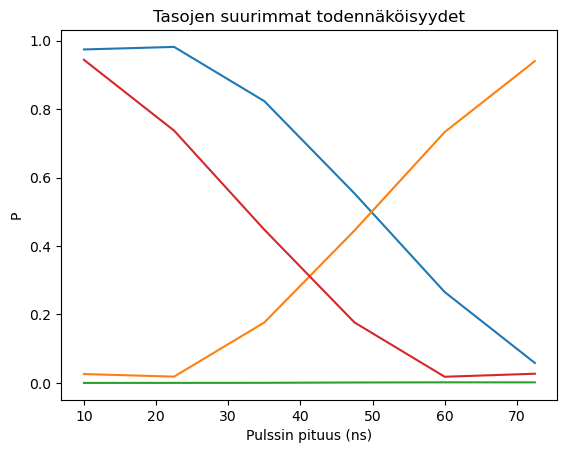

---------------------------------------------


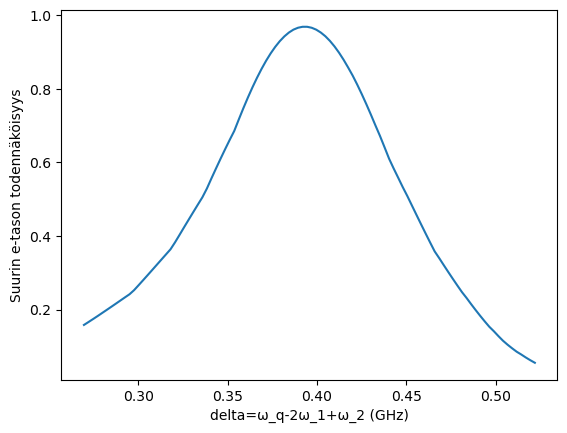

Amplitudi (GHz): 2.9781418465636382
AC-stark siirtymä (GHz): 0.3918895024146565
E-tason suurin todennäköisyys: 0.9973187606651273
Pulssin pituus (ns): 66.33075362523542
Rabi-taajuus (fourier):  0.008794713582790752


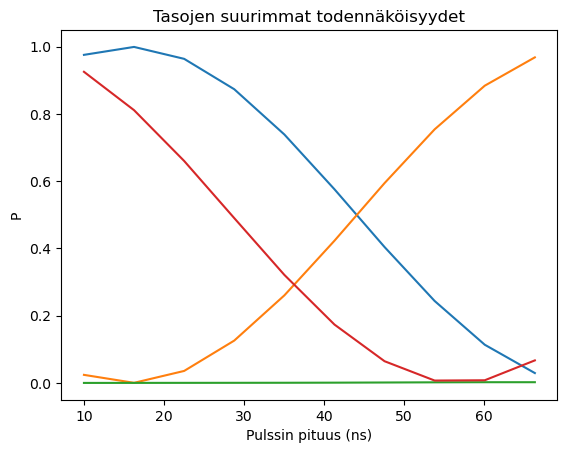

---------------------------------------------


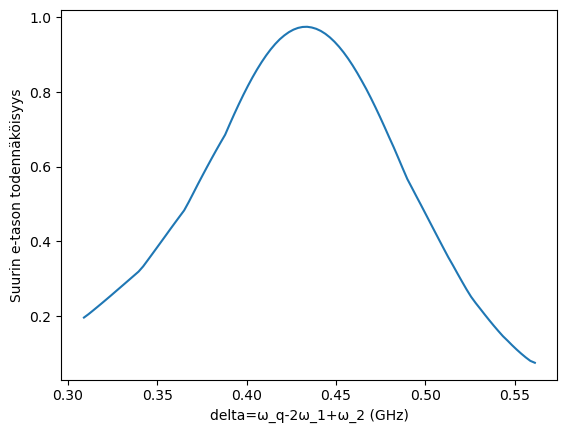

Amplitudi (GHz): 3.112292380192631
AC-stark siirtymä (GHz): 0.4338763062144153
E-tason suurin todennäköisyys: 0.9979576034452846
Pulssin pituus (ns): 60.15569148167617
Rabi-taajuus (fourier):  0.010181063859101544


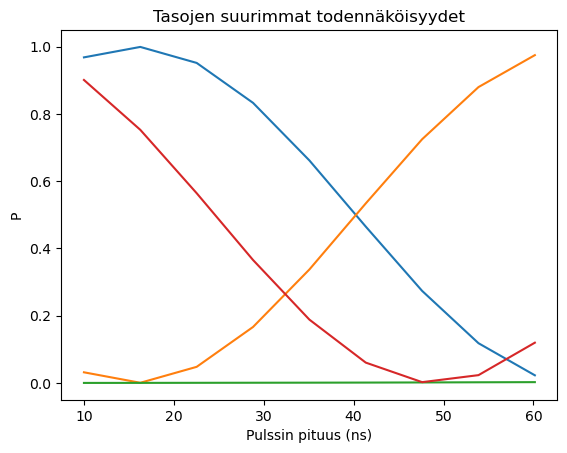

---------------------------------------------


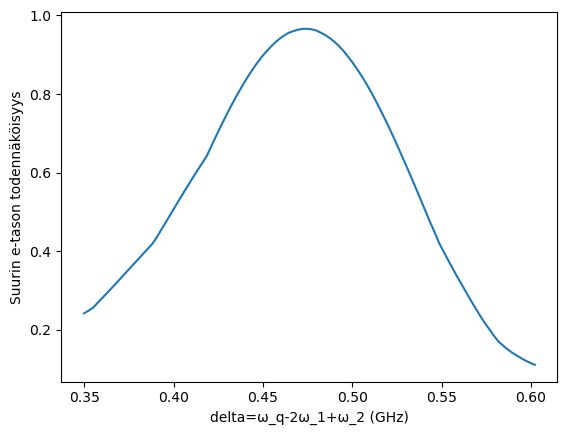

Amplitudi (GHz): 3.2464429138216238
AC-stark siirtymä (GHz): 0.4746637517214296
E-tason suurin todennäköisyys: 0.9961248145117216
Pulssin pituus (ns): 53.9577904398141
Rabi-taajuus (fourier):  0.011651976062184115


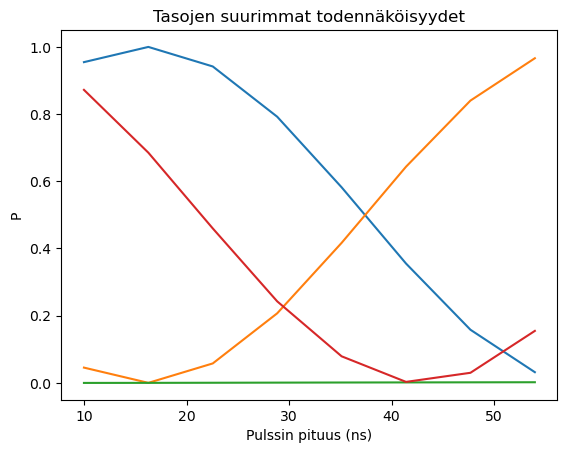

---------------------------------------------


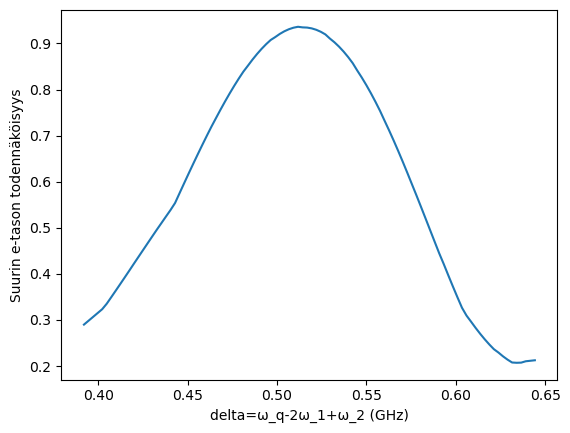

Amplitudi (GHz): 3.3805934474506167
AC-stark siirtymä (GHz): 0.5117029787967553
E-tason suurin todennäköisyys: 0.9940978727261076
Pulssin pituus (ns): 47.73398043981061
Rabi-taajuus (fourier):  0.013437285110430078


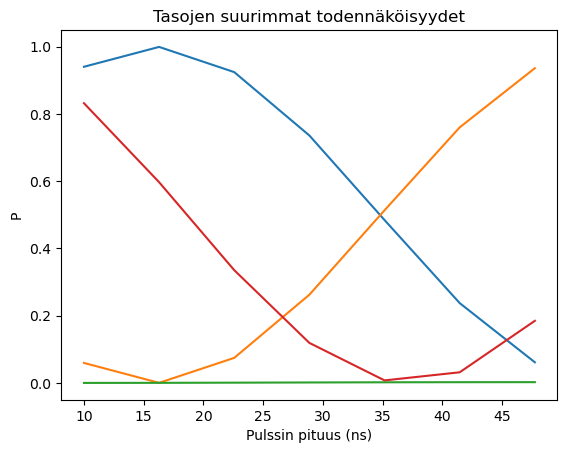

---------------------------------------------


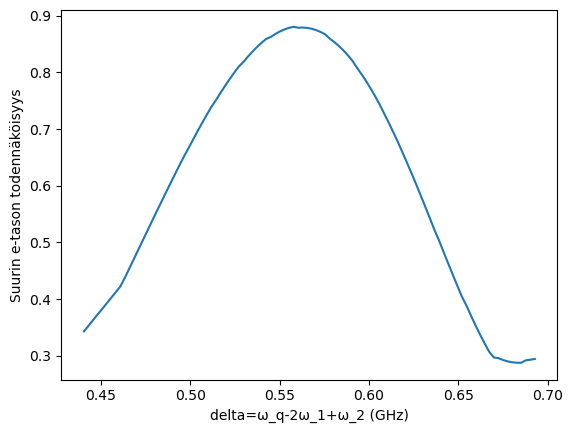

Amplitudi (GHz): 3.5147439810796093
AC-stark siirtymä (GHz): 0.5577382881351411
E-tason suurin todennäköisyys: 0.9888888154086252
Pulssin pituus (ns): 41.503047455833155
Rabi-taajuus (fourier):  0.015359497154055204


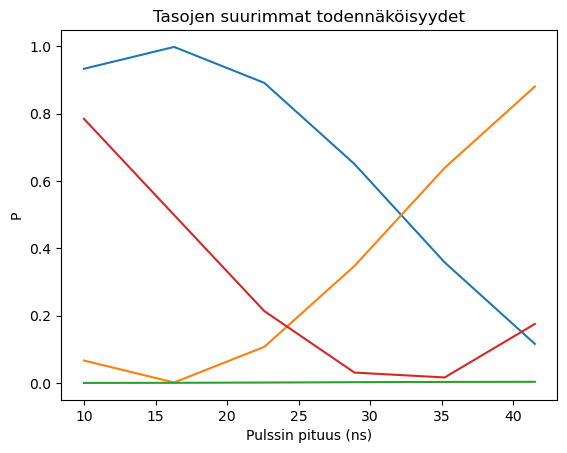

---------------------------------------------


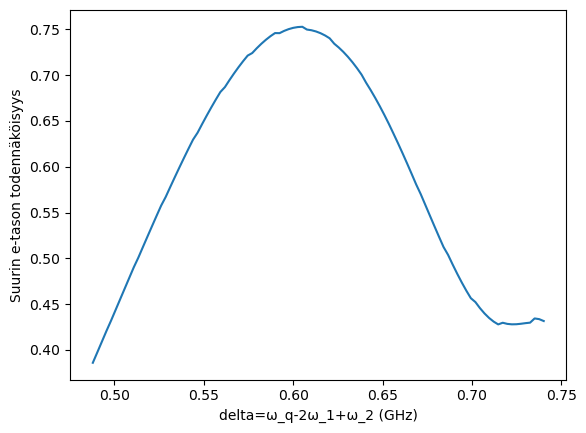

Amplitudi (GHz): 3.648894514708602
AC-stark siirtymä (GHz): 0.6051230993197336
E-tason suurin todennäköisyys: 0.9907347473221136
Pulssin pituus (ns): 35.250430160549286
Rabi-taajuus (fourier):  0.017281433765251306


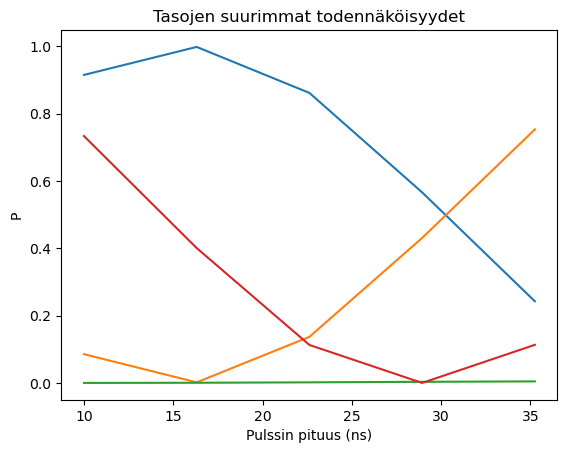

---------------------------------------------


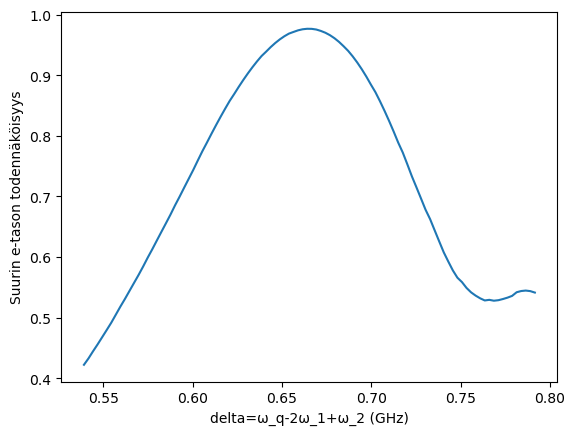

Amplitudi (GHz): 3.783045048337595
AC-stark siirtymä (GHz): 0.6640528529063303
E-tason suurin todennäköisyys: 0.9925928528215344
Pulssin pituus (ns): 39.10692652719433
Rabi-taajuus (fourier):  0.019591485667561654


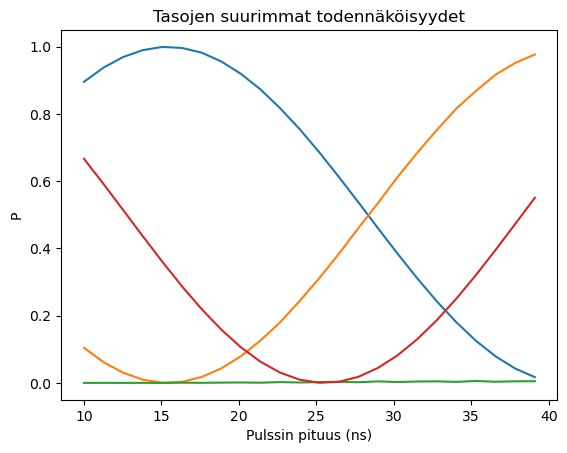

---------------------------------------------


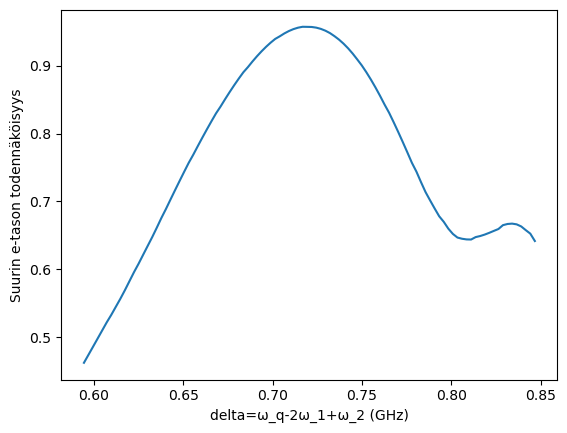

Amplitudi (GHz): 3.9171955819665873
AC-stark siirtymä (GHz): 0.7166855279222872
E-tason suurin todennäköisyys: 0.9943346002280785
Pulssin pituus (ns): 35.364147618969135
Rabi-taajuus (fourier):  0.022107885191932658


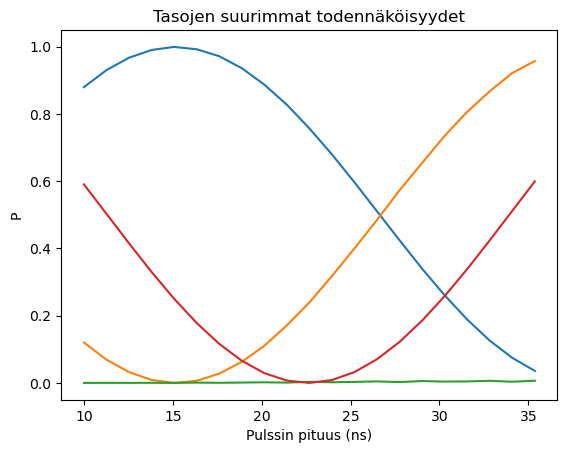

---------------------------------------------


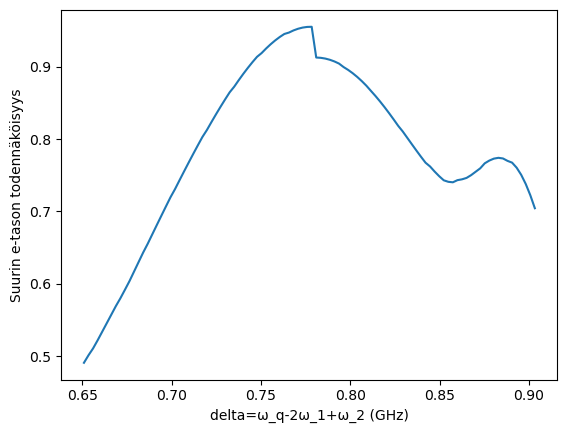

Amplitudi (GHz): 4.05134611559558
AC-stark siirtymä (GHz): 0.7783142852013043
E-tason suurin todennäköisyys: 0.9938837290834266
Pulssin pituus (ns): 32.88466642492354
Rabi-taajuus (fourier):  0.024838511607602677


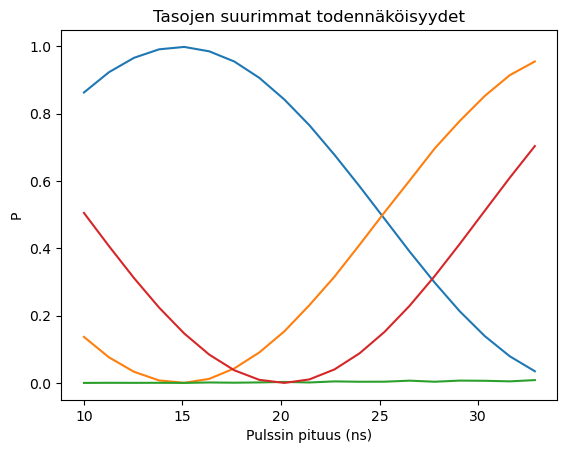

---------------------------------------------


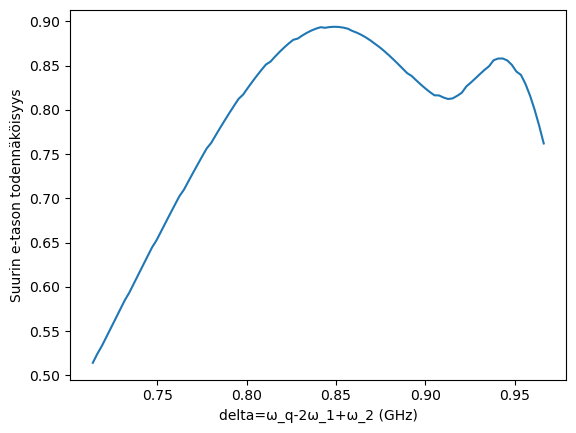

Amplitudi (GHz): 4.185496649224572
AC-stark siirtymä (GHz): 0.8489391247433815
E-tason suurin todennäköisyys: 0.979098692351044
Pulssin pituus (ns): 29.125217422819205
Rabi-taajuus (fourier):  0.028010886039658817


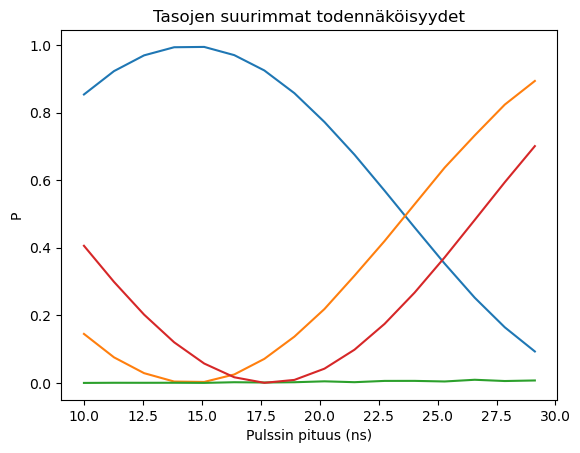

---------------------------------------------


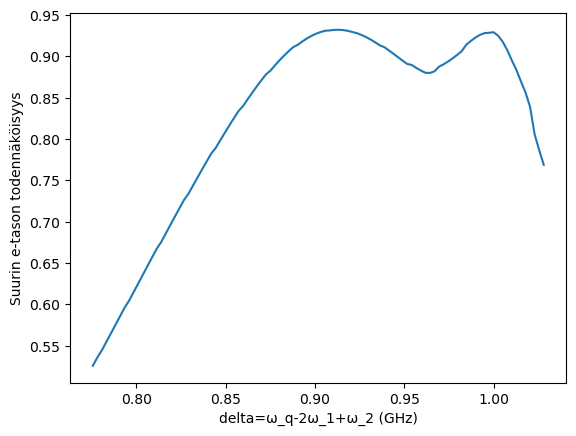

Amplitudi (GHz): 4.319647182853566
AC-stark siirtymä (GHz): 0.913266885714819
E-tason suurin todennäköisyys: 0.9771693851162622
Pulssin pituus (ns): 27.896927158190817
Rabi-taajuus (fourier):  0.031290287715324765


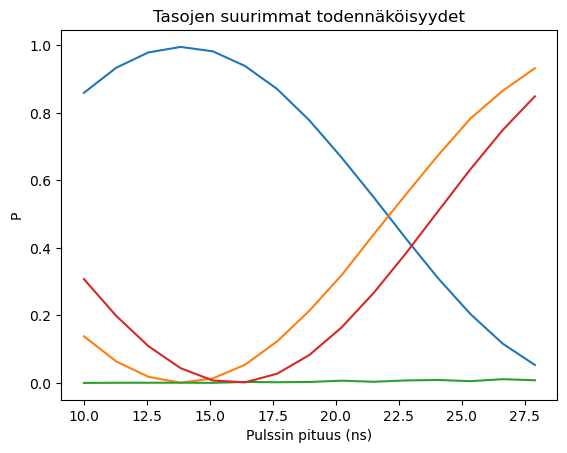

---------------------------------------------


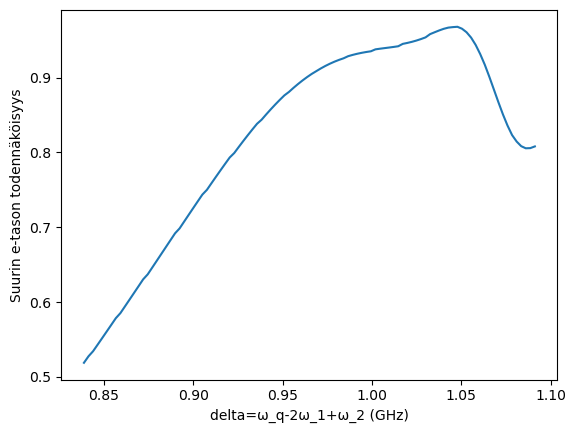

Amplitudi (GHz): 4.453797716482558
AC-stark siirtymä (GHz): 1.0477633722841304
E-tason suurin todennäköisyys: 0.9740880260503822
Pulssin pituus (ns): 25.42463962017561
Rabi-taajuus (fourier):  0.0348347479141755


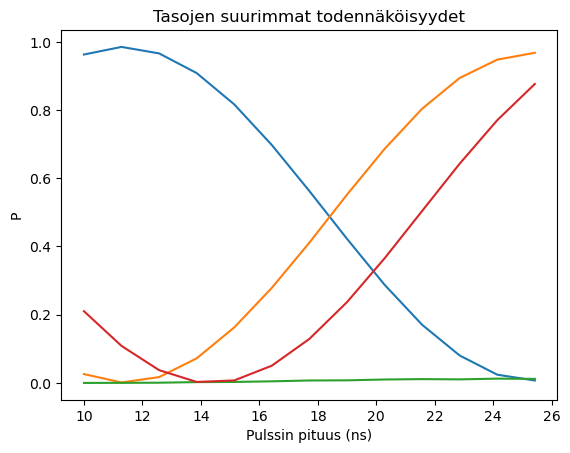

---------------------------------------------


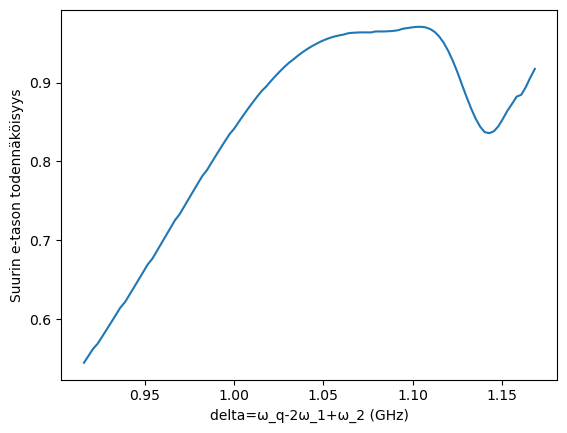

Amplitudi (GHz): 4.587948250111551
AC-stark siirtymä (GHz): 1.1045946963921764
E-tason suurin todennäköisyys: 0.9739025478085729
Pulssin pituus (ns): 24.17220706359273
Rabi-taajuus (fourier):  0.0388083519759534


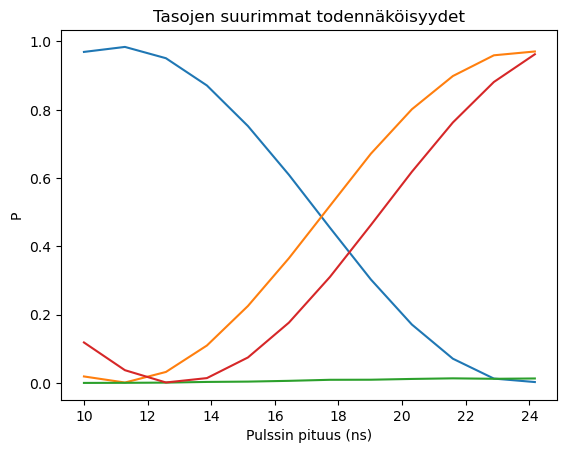

---------------------------------------------


In [ ]:
c_vals = [] #c:n arvot
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.08
max_range = 0.18
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    
    f_supp_opt=f_ef

    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    
    if i < 5:
        params=find_params(f_1,f_2,f_supp_opt,A,evolution_eigenbasis,8*f_rabi,list_c_vals[i],[-25,25],10000)
    else:
        params=find_params(f_1,f_2,f_supp_opt,A,evolution_eigenbasis,8*f_rabi,list_c_vals[i],[-50,50],10000)

    c_vals.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])

    f_1_opt=f_1*c_vals[-1]
    f_2_opt=f_2*c_vals[-1]
    deltas.append(qubit.frequency-2*f_1_opt+f_2_opt)

    m=10

    if A < 2.9:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_supp_opt,A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=10,f_2=f_2_opt,K=200,drag=True)
    elif A < 3.7:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_supp_opt,A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=5,f_2=f_2_opt,K=200,drag=True)
    else:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_supp_opt,A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=1,f_2=f_2_opt,K=200,drag=True)
    
    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(2.0390881111606896), np.float64(2.173238644789682), np.float64(2.307389178418675), np.float64(2.4415397120476676), np.float64(2.57569024567666), np.float64(2.7098407793056527), np.float64(2.8439913129346457), np.float64(2.9781418465636382), np.float64(3.112292380192631), np.float64(3.2464429138216238), np.float64(3.3805934474506167), np.float64(3.5147439810796093), np.float64(3.648894514708602), np.float64(3.783045048337595), np.float64(3.9171955819665873), np.float64(4.05134611559558), np.float64(4.185496649224572), np.float64(4.319647182853566), np.float64(4.453797716482558), np.float64(4.587948250111551)]


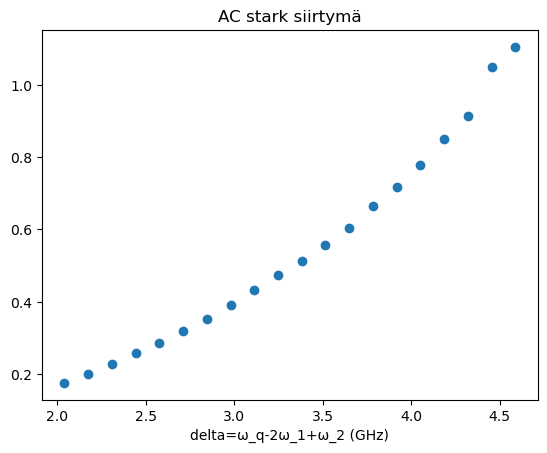

[np.float64(0.17654968973334917), np.float64(0.20144340019280094), np.float64(0.22768661249846645), np.float64(0.25782818678928976), np.float64(0.28677040278736143), np.float64(0.319610980770598), np.float64(0.35380106060004834), np.float64(0.3918895024146565), np.float64(0.4338763062144153), np.float64(0.4746637517214296), np.float64(0.5117029787967553), np.float64(0.5577382881351411), np.float64(0.6051230993197336), np.float64(0.6640528529063303), np.float64(0.7166855279222872), np.float64(0.7783142852013043), np.float64(0.8489391247433815), np.float64(0.913266885714819), np.float64(1.0477633722841304), np.float64(1.1045946963921764)]
[np.float64(0.9930733865293206), np.float64(0.9920967260182538), np.float64(0.9910671201993773), np.float64(0.989884569072691), np.float64(0.9887490726381949), np.float64(0.9874606308958891), np.float64(0.9861192438457734), np.float64(0.9846249114878481), np.float64(0.9829776338221131), np.float64(0.9813774108485682), np.float64(0.9799242425672137), np.

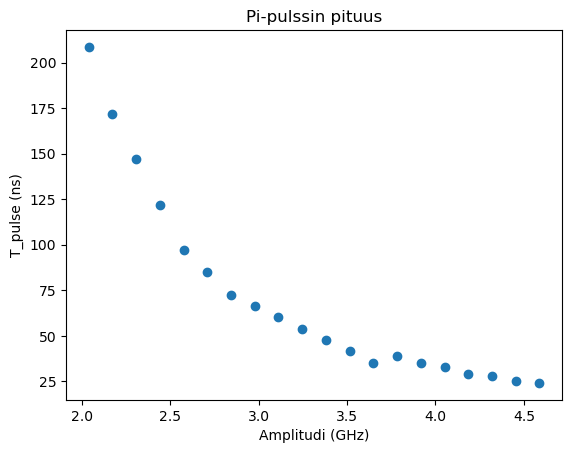

[np.float64(208.5832008152977), np.float64(171.5076890567263), np.float64(146.8023268141436), np.float64(122.06289103839585), np.float64(97.26012243600714), np.float64(84.8919826160158), np.float64(72.49487985740069), np.float64(66.33075362523542), np.float64(60.15569148167617), np.float64(53.9577904398141), np.float64(47.73398043981061), np.float64(41.503047455833155), np.float64(35.250430160549286), np.float64(39.10692652719433), np.float64(35.364147618969135), np.float64(32.88466642492354), np.float64(29.125217422819205), np.float64(27.896927158190817), np.float64(25.42463962017561), np.float64(24.17220706359273)]


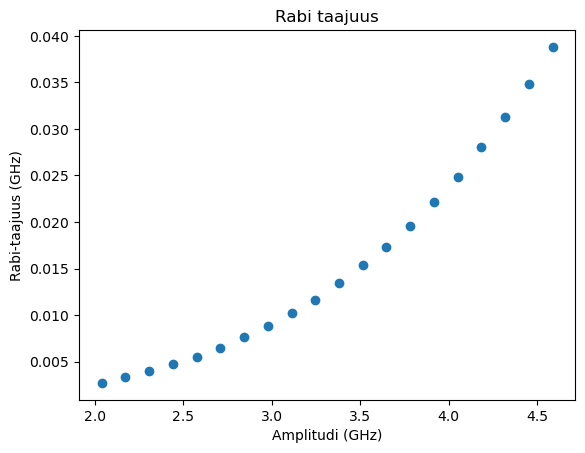

[np.float64(0.0027158684142585474), np.float64(0.0033078708417084864), np.float64(0.003987173012017457), np.float64(0.004724237968521543), np.float64(0.00553240824345267), np.float64(0.00649584200462134), np.float64(0.007619671839949704), np.float64(0.008794713582790752), np.float64(0.010181063859101544), np.float64(0.011651976062184115), np.float64(0.013437285110430078), np.float64(0.015359497154055204), np.float64(0.017281433765251306), np.float64(0.019591485667561654), np.float64(0.022107885191932658), np.float64(0.024838511607602677), np.float64(0.028010886039658817), np.float64(0.031290287715324765), np.float64(0.0348347479141755), np.float64(0.0388083519759534)]


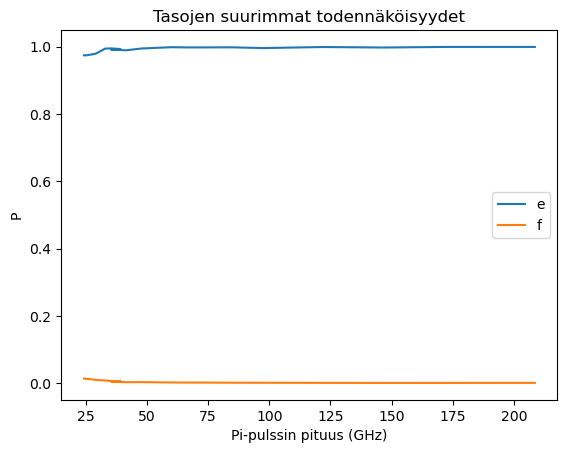

[np.float64(0.9987921365234977), np.float64(0.9987393818319121), np.float64(0.9970177930380887), np.float64(0.9984911524408823), np.float64(0.9953771927068157), np.float64(0.9976037875106188), np.float64(0.9973764470897155), np.float64(0.9973187606651273), np.float64(0.9979576034452846), np.float64(0.9961248145117216), np.float64(0.9940978727261076), np.float64(0.9888888154086252), np.float64(0.9907347473221136), np.float64(0.9925928528215344), np.float64(0.9943346002280785), np.float64(0.9938837290834266), np.float64(0.979098692351044), np.float64(0.9771693851162622), np.float64(0.9740880260503822), np.float64(0.9739025478085729)]
[np.float64(0.0013859370508523792), np.float64(0.001261155316614624), np.float64(0.001231020890395998), np.float64(0.0013815499246193428), np.float64(0.0017023989680260865), np.float64(0.0018370757264256129), np.float64(0.002363513284740986), np.float64(0.002243033049198567), np.float64(0.002564188480928177), np.float64(0.0030457952677162507), np.float64(0.0

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """